# Customer Churn Prediction & Customer Behavior Analysis

### Predicting Customer Churn Using Behavioral, Transactional, and Engagement Data

---

## Project Overview

This project analyzes customer behavior and develops a machine learning model to identify customers with a higher likelihood of churn.

The analysis combines customer profile, transaction history, and customer interaction data to understand behavioral patterns associated with churn.

The project follows an end-to-end data science workflow, including data validation, data cleaning, exploratory data analysis, data integration, feature engineering, machine learning modeling, model evaluation, and business recommendations.

---

## Business Problem

How can customers with a higher risk of churn be identified based on their characteristics and behavioral patterns?

This project focuses on answering the following questions:

1. What characteristics are associated with customers who churn?
2. Is transaction activity related to customer churn?
3. Is customer engagement related to churn?
4. Which factors are most influential in predicting churn?
5. How well can machine learning models predict customer churn?

---

## Project Objective

The main objective of this project is to build a machine learning model that predicts customer churn based on customer profile, transaction behavior, and engagement activity.

Additional objectives include:

- Performing data validation and cleaning.
- Conducting exploratory data analysis.
- Integrating multiple customer-related datasets.
- Creating behavioral and engagement features.
- Identifying patterns associated with customer churn.
- Comparing multiple machine learning algorithms.
- Evaluating model performance using relevant classification metrics.
- Generating business insights and customer retention recommendations.

In [2]:
# ============================================
# CUSTOMER CHURN PREDICTION & CUSTOMER BEHAVIOR ANALYSIS
# ============================================
# Predicting Customer Churn Using Behavioral,
# Transactional, and Engagement Data

import os
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Customer Churn Prediction & Customer Behavior Analysis")
print("Project environment ready!")

Customer Churn Prediction & Customer Behavior Analysis
Project environment ready!


## Dataset

The project uses the CRROS Customer Behavior Dataset consisting of four raw datasets:

- `customers.csv` — customer profile information
- `products.csv` — product information
- `transactions.csv` — customer transaction history
- `interactions.csv` — customer interaction and engagement activity

The raw datasets are processed and integrated to create a customer-level analytical dataset for churn analysis and machine learning.

In [4]:
# ============================================
# CELL 2 — DATA LOADING
# ============================================

RAW_PATH = "D:/PORTO/customer-churn-prediction/data/raw"

customers = pd.read_csv(
    os.path.join(RAW_PATH, "customers.csv")
)

products = pd.read_csv(
    os.path.join(RAW_PATH, "products.csv")
)

transactions = pd.read_csv(
    os.path.join(RAW_PATH, "transactions.csv")
)

interactions = pd.read_csv(
    os.path.join(RAW_PATH, "interactions.csv")
)

print("Data successfully loaded!")

print("\nCustomers:")
print(customers.shape)

print("\nProducts:")
print(products.shape)

print("\nTransactions:")
print(transactions.shape)

print("\nInteractions:")
print(interactions.shape)

Data successfully loaded!

Customers:
(8000, 7)

Products:
(120, 5)

Transactions:
(24431, 7)

Interactions:
(250000, 6)


## 2. Data Understanding

This section examines the structure, dimensions, columns, data types, and sample records of each dataset.

In [6]:
# ============================================
# CELL 3 — DATA UNDERSTANDING
# ============================================

datasets = {
    "Customers": customers,
    "Products": products,
    "Transactions": transactions,
    "Interactions": interactions
}

for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())


CUSTOMERS
Shape: (8000, 7)

Columns:
['customer_id', 'signup_date', 'customer_segment', 'location', 'acquisition_channel', 'age', 'gender']

Data Types:
customer_id            object
signup_date            object
customer_segment       object
location               object
acquisition_channel    object
age                     int64
gender                 object
dtype: object

First 5 Rows:


,customer_id,signup_date,customer_segment,location,acquisition_channel,age,gender
0,C00001,2024-04-12,medium,Bhubaneswar,ads,25,male
1,C00002,2025-03-11,high,Hyderabad,referral,47,female
2,C00003,2024-09-27,low,Ahmedabad,organic,46,female
3,C00004,2024-04-16,medium,Bangalore,organic,38,male
4,C00005,2024-03-12,high,Hyderabad,referral,37,female



PRODUCTS
Shape: (120, 5)

Columns:
['product_id', 'category', 'price', 'cost', 'launch_date']

Data Types:
product_id      object
category        object
price            int64
cost           float64
launch_date     object
dtype: object

First 5 Rows:


,product_id,category,price,cost,launch_date
0,P0001,clothing,4758,3463.85,2025-12-12
1,P0002,beauty,1370,974.63,2024-11-20
2,P0003,electronics,49187,38650.16,2025-11-01
3,P0004,electronics,16775,10131.04,2025-03-03
4,P0005,home,8411,6297.29,2024-05-20



TRANSACTIONS
Shape: (24431, 7)

Columns:
['transaction_id', 'customer_id', 'product_id', 'transaction_date', 'quantity', 'price', 'discount']

Data Types:
transaction_id        int64
customer_id          object
product_id           object
transaction_date     object
quantity              int64
price                 int64
discount            float64
dtype: object

First 5 Rows:


,transaction_id,customer_id,product_id,transaction_date,quantity,price,discount
0,1,C00001,P0078,2024-05-18,1,30202,0.07
1,2,C00001,P0007,2024-05-26,3,16826,0.04
2,3,C00001,P0082,2024-05-22,2,6509,0.05
3,4,C00001,P0115,2024-08-14,3,7554,0.20
4,5,C00001,P0065,2024-09-05,1,4389,0.01



INTERACTIONS
Shape: (250000, 6)

Columns:
['interaction_id', 'customer_id', 'interaction_type', 'product_id', 'interaction_timestamp', 'channel']

Data Types:
interaction_id            int64
customer_id              object
interaction_type         object
product_id               object
interaction_timestamp    object
channel                  object
dtype: object

First 5 Rows:


,interaction_id,customer_id,interaction_type,product_id,interaction_timestamp,channel
0,1,C00001,view,P0069,2024-04-18,app
1,2,C00001,click,NaN,2024-04-27,web
2,3,C00001,click,NaN,2024-05-06,app
3,4,C00001,click,NaN,2024-05-23,web
4,5,C00001,view,P0033,2024-05-05,app


## 3. Data Validation

The validation process checks missing values, duplicate records, and primary key uniqueness across the datasets.

In [8]:
# ============================================
# CELL 4 — DATA VALIDATION
# ============================================

validation_results = []

for name, df in datasets.items():

    for column in df.columns:

        missing_count = df[column].isna().sum()
        duplicate_count = df[column].duplicated().sum()

        validation_results.append({
            "Dataset": name,
            "Column": column,
            "Missing Value": missing_count,
            "Duplicate Value": duplicate_count
        })

validation_df = pd.DataFrame(validation_results)

print("=== DATA VALIDATION ===")
display(validation_df)

=== DATA VALIDATION ===


,Dataset,Column,Missing Value,Duplicate Value
0,Customers,customer_id,0,0
1,Customers,signup_date,0,7269
2,Customers,customer_segment,0,7997
3,Customers,location,0,7990
4,Customers,acquisition_channel,0,7997
5,Customers,age,0,7952
6,Customers,gender,0,7997
7,Products,product_id,0,0
8,Products,category,0,115
9,Products,price,0,0


In [9]:
# ============================================
# DUPLICATE RECORD VALIDATION
# ============================================

print("=== DUPLICATE RECORD VALIDATION ===")

for name, df in datasets.items():

    duplicate_rows = df.duplicated().sum()

    print(
        f"{name}: {duplicate_rows} duplicate rows"
    )

=== DUPLICATE RECORD VALIDATION ===
Customers: 0 duplicate rows
Products: 0 duplicate rows
Transactions: 0 duplicate rows
Interactions: 0 duplicate rows


In [10]:
# ============================================
# PRIMARY KEY VALIDATION
# ============================================

primary_keys = {
    "Customers": "customer_id",
    "Products": "product_id",
    "Transactions": "transaction_id",
    "Interactions": "interaction_id"
}

print("=== PRIMARY KEY VALIDATION ===")

for name, key in primary_keys.items():

    df = datasets[name]

    if key in df.columns:

        duplicate_keys = df[key].duplicated().sum()
        missing_keys = df[key].isna().sum()

        print(f"\n{name}")
        print(f"{key} missing  : {missing_keys}")
        print(f"{key} duplicate: {duplicate_keys}")

    else:

        print(
            f"\n{name}: column '{key}' tidak ditemukan."
        )

=== PRIMARY KEY VALIDATION ===

Customers
customer_id missing  : 0
customer_id duplicate: 0

Products
product_id missing  : 0
product_id duplicate: 0

Transactions
transaction_id missing  : 0
transaction_id duplicate: 0

Interactions
interaction_id missing  : 0
interaction_id duplicate: 0


## 4. Data Cleaning

The datasets are cleaned by removing duplicate records, converting date columns into appropriate datetime formats, converting numeric variables, and handling basic missing values.

In [12]:
# ============================================
# CELL 5 — DATA CLEANING
# ============================================

customers_clean = customers.copy()
products_clean = products.copy()
transactions_clean = transactions.copy()
interactions_clean = interactions.copy()

# --------------------------------------------
# Remove duplicate records
# --------------------------------------------

customers_clean = customers_clean.drop_duplicates()
products_clean = products_clean.drop_duplicates()
transactions_clean = transactions_clean.drop_duplicates()
interactions_clean = interactions_clean.drop_duplicates()

# --------------------------------------------
# Convert date columns
# --------------------------------------------

customers_clean["signup_date"] = pd.to_datetime(
    customers_clean["signup_date"],
    errors="coerce"
)

transactions_clean["transaction_date"] = pd.to_datetime(
    transactions_clean["transaction_date"],
    errors="coerce"
)

interactions_clean["interaction_timestamp"] = pd.to_datetime(
    interactions_clean["interaction_timestamp"],
    errors="coerce"
)

# --------------------------------------------
# Numeric columns
# --------------------------------------------

transaction_numeric_columns = [
    "price",
    "quantity",
    "discount"
]

for column in transaction_numeric_columns:

    if column in transactions_clean.columns:

        transactions_clean[column] = pd.to_numeric(
            transactions_clean[column],
            errors="coerce"
        )

# --------------------------------------------
# Basic missing value handling
# --------------------------------------------

for column in ["price", "quantity", "discount"]:

    if column in transactions_clean.columns:

        transactions_clean[column] = (
            transactions_clean[column].fillna(0)
        )

print("Data cleaning completed!")

print("\nCustomers:", customers_clean.shape)
print("Products:", products_clean.shape)
print("Transactions:", transactions_clean.shape)
print("Interactions:", interactions_clean.shape)

Data cleaning completed!

Customers: (8000, 7)
Products: (120, 5)
Transactions: (24431, 7)
Interactions: (250000, 6)


## 5. Exploratory Data Analysis

Initial exploratory analysis is performed to understand customer characteristics, interaction patterns, and the available observation periods.

In [14]:
# ============================================
# CELL 6 — EXPLORATORY DATA ANALYSIS
# 6A — DATE RANGE
# ============================================

print("=== TRANSACTION DATE ===")

print(
    "Min:",
    transactions_clean["transaction_date"].min()
)

print(
    "Max:",
    transactions_clean["transaction_date"].max()
)

print("\n=== INTERACTION DATE ===")

print(
    "Min:",
    interactions_clean["interaction_timestamp"].min()
)

print(
    "Max:",
    interactions_clean["interaction_timestamp"].max()
)

print("\n=== SIGNUP DATE ===")

print(
    "Min:",
    customers_clean["signup_date"].min()
)

print(
    "Max:",
    customers_clean["signup_date"].max()
)

=== TRANSACTION DATE ===
Min: 2024-01-06 00:00:00
Max: 2026-03-31 00:00:00

=== INTERACTION DATE ===
Min: 2024-01-01 00:00:00
Max: 2026-03-31 00:00:00

=== SIGNUP DATE ===
Min: 2024-01-01 00:00:00
Max: 2025-12-31 00:00:00


customer_segment
medium    4053
low       2331
high      1616
Name: count, dtype: int64


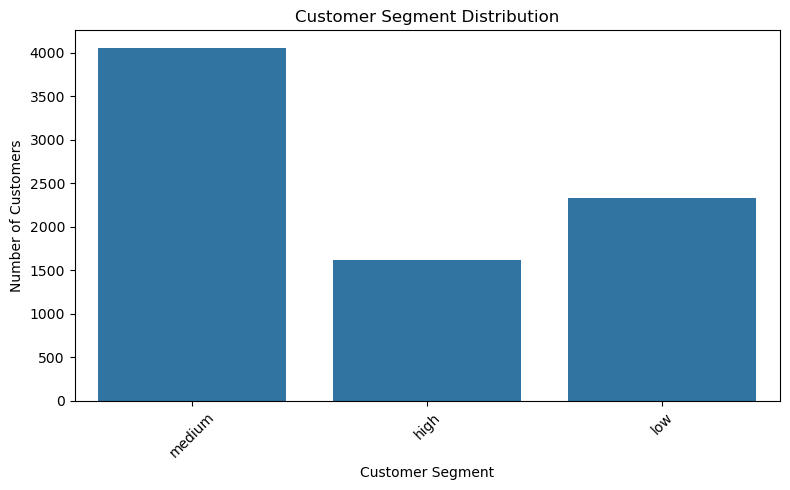

In [154]:
# ============================================
# 6B — CUSTOMER SEGMENT DISTRIBUTION
# ============================================

if "customer_segment" in customers_clean.columns:

    print(
        customers_clean["customer_segment"].value_counts()
    )

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=customers_clean,
        x="customer_segment"
    )

    plt.title("Customer Segment Distribution")
    plt.xlabel("Customer Segment")
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "churn_by_customer_segment.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

interaction_type
view           124806
click           62609
add_to_cart     37666
email_open      24919
Name: count, dtype: int64


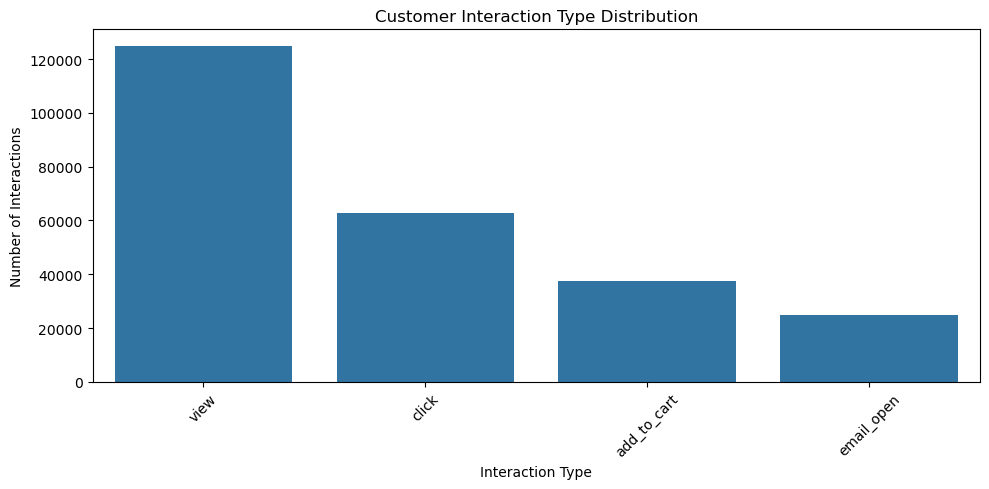

In [17]:
# ============================================
# 6C — INTERACTION TYPE DISTRIBUTION
# ============================================

if "interaction_type" in interactions_clean.columns:

    print(
        interactions_clean["interaction_type"].value_counts()
    )

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=interactions_clean,
        x="interaction_type"
    )

    plt.title("Customer Interaction Type Distribution")
    plt.xlabel("Interaction Type")
    plt.ylabel("Number of Interactions")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 6. Historical & Outcome Period

In [24]:
# ============================================
# CELL 7 — HISTORICAL & OUTCOME PERIOD
# ============================================

reference_date = pd.Timestamp("2025-12-31")
outcome_start = pd.Timestamp("2026-01-01")
outcome_end = pd.Timestamp("2026-03-31")

print("Historical period:")
print("Up to:", reference_date)

print("\nOutcome period:")
print("Start:", outcome_start)
print("End  :", outcome_end)

Historical period:
Up to: 2025-12-31 00:00:00

Outcome period:
Start: 2026-01-01 00:00:00
End  : 2026-03-31 00:00:00


In [25]:
# ============================================
# HISTORICAL DATA
# ============================================

transactions_hist = transactions_clean[
    transactions_clean["transaction_date"] <= reference_date
].copy()

interactions_hist = interactions_clean[
    interactions_clean["interaction_timestamp"] <= reference_date
].copy()

print("Historical Transactions:", transactions_hist.shape)
print("Historical Interactions:", interactions_hist.shape)

print(
    "\nHistorical Transaction Date:",
    transactions_hist["transaction_date"].min(),
    "to",
    transactions_hist["transaction_date"].max()
)

print(
    "\nHistorical Interaction Date:",
    interactions_hist["interaction_timestamp"].min(),
    "to",
    interactions_hist["interaction_timestamp"].max()
)

Historical Transactions: (19642, 7)
Historical Interactions: (201559, 6)

Historical Transaction Date: 2024-01-06 00:00:00 to 2025-12-31 00:00:00

Historical Interaction Date: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [28]:
# ============================================
# OUTCOME DATA
# ============================================

transactions_outcome = transactions_clean[
    (
        transactions_clean["transaction_date"] >= outcome_start
    )
    &
    (
        transactions_clean["transaction_date"] <= outcome_end
    )
].copy()

print("Outcome Transactions:", transactions_outcome.shape)

print(
    "Outcome Date:",
    transactions_outcome["transaction_date"].min(),
    "to",
    transactions_outcome["transaction_date"].max()
)

Outcome Transactions: (4789, 7)
Outcome Date: 2026-01-01 00:00:00 to 2026-03-31 00:00:00


## 7. Transaction Feature Engineering

In [31]:
# ============================================
# CELL 8 — TRANSACTION FEATURE ENGINEERING
# ============================================

transactions_hist["revenue"] = (
    transactions_hist["price"]
    *
    transactions_hist["quantity"]
    *
    (1 - transactions_hist["discount"])
)

transaction_features = (
    transactions_hist
    .groupby("customer_id")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),

        total_spending=(
            "revenue",
            "sum"
        ),

        average_transaction_value=(
            "revenue",
            "mean"
        ),

        unique_products=(
            "product_id",
            "nunique"
        ),

        last_purchase_date=(
            "transaction_date",
            "max"
        )
    )
    .reset_index()
)

transaction_features["days_since_last_purchase"] = (
    reference_date
    -
    transaction_features["last_purchase_date"]
).dt.days

transaction_features["purchase_frequency"] = (
    transaction_features["total_transactions"]
)

print("=== TRANSACTION FEATURES ===")

display(
    transaction_features.head()
)

print(
    "\nShape:",
    transaction_features.shape
)

=== TRANSACTION FEATURES ===


,customer_id,total_transactions,total_spending,average_transaction_value,unique_products,last_purchase_date,days_since_last_purchase,purchase_frequency
0,C00001,27,460370.34,17050.753333,23,2025-12-26,5,27
1,C00002,38,714174.05,18794.053947,28,2025-12-29,2,38
2,C00004,28,503765.64,17991.630000,24,2025-10-26,66,28
3,C00005,87,1336938.00,15367.103448,67,2025-12-23,8,87
4,C00006,6,63302.92,10550.486667,6,2025-12-30,1,6



Shape: (967, 8)


## 8. Engagement Feature Engineering

In [33]:
# ============================================
# CELL 9 — ENGAGEMENT FEATURE ENGINEERING
# ============================================

interaction_features = (
    interactions_hist
    .groupby("customer_id")
    .agg(
        total_interactions=(
            "interaction_id",
            "count"
        ),

        interaction_types_count=(
            "interaction_type",
            "nunique"
        ),

        last_interaction_date=(
            "interaction_timestamp",
            "max"
        )
    )
    .reset_index()
)

interaction_features["days_since_last_interaction"] = (
    reference_date
    -
    interaction_features["last_interaction_date"]
).dt.days

print("=== INTERACTION FEATURES ===")

display(
    interaction_features.head()
)

print(
    "\nShape:",
    interaction_features.shape
)

=== INTERACTION FEATURES ===


,customer_id,total_interactions,interaction_types_count,last_interaction_date,days_since_last_interaction
0,C00001,289,4,2025-12-27,4
1,C00002,311,4,2025-12-29,2
2,C00003,8,4,2024-10-30,427
3,C00004,275,4,2025-12-31,0
4,C00005,670,4,2025-12-31,0



Shape: (1196, 5)


## 9. Additional Engagement Features

In [36]:
# ============================================
# CELL 10 — ADDITIONAL ENGAGEMENT FEATURES
# ============================================

interaction_type_text = (
    interactions_hist["interaction_type"]
    .astype(str)
    .str.lower()
)

# Website-related interactions
website_mask = interaction_type_text.str.contains(
    "website|web|visit",
    regex=True,
    na=False
)

# Marketing-related interactions
marketing_mask = interaction_type_text.str.contains(
    "marketing|email|campaign|promotion|promo|ads",
    regex=True,
    na=False
)

website_visits = (
    interactions_hist.loc[website_mask]
    .groupby("customer_id")
    .size()
    .rename("website_visits")
)

marketing_interactions = (
    interactions_hist.loc[marketing_mask]
    .groupby("customer_id")
    .size()
    .rename("marketing_interactions")
)

interaction_features = interaction_features.merge(
    website_visits,
    on="customer_id",
    how="left"
)

interaction_features = interaction_features.merge(
    marketing_interactions,
    on="customer_id",
    how="left"
)

interaction_features[
    [
        "website_visits",
        "marketing_interactions"
    ]
] = interaction_features[
    [
        "website_visits",
        "marketing_interactions"
    ]
].fillna(0)

# Engagement frequency
days_in_historical_period = (
    reference_date
    - transactions_hist["transaction_date"].min()
).days

if days_in_historical_period > 0:

    interaction_features["engagement_frequency"] = (
        interaction_features["total_interactions"]
        /
        days_in_historical_period
    )

else:

    interaction_features["engagement_frequency"] = (
        interaction_features["total_interactions"]
    )

print("=== ENGAGEMENT FEATURES ===")

display(
    interaction_features.head()
)

=== ENGAGEMENT FEATURES ===


,customer_id,total_interactions,interaction_types_count,last_interaction_date,days_since_last_interaction,website_visits,marketing_interactions,engagement_frequency
0,C00001,289,4,2025-12-27,4,0.0,37.0,0.398621
1,C00002,311,4,2025-12-29,2,0.0,28.0,0.428966
2,C00003,8,4,2024-10-30,427,0.0,1.0,0.011034
3,C00004,275,4,2025-12-31,0,0.0,26.0,0.379310
4,C00005,670,4,2025-12-31,0,0.0,59.0,0.924138


## 10. Data Integration

In [41]:
# ============================================
# CELL 11 — DATA INTEGRATION
# ============================================

customer_profile = customers_clean[
    [
        "customer_id",
        "customer_segment",
        "location",
        "acquisition_channel",
        "age",
        "gender",
        "signup_date"
    ]
].copy()

customer_dataset = customer_profile.merge(
    transaction_features,
    on="customer_id",
    how="left"
)

customer_dataset = customer_dataset.merge(
    interaction_features,
    on="customer_id",
    how="left"
)

print("=== CUSTOMER DATASET AFTER INTEGRATION ===")

print(
    "Shape:",
    customer_dataset.shape
)

print("\nColumns:")
print(
    customer_dataset.columns.tolist()
)

display(
    customer_dataset.head()
)

=== CUSTOMER DATASET AFTER INTEGRATION ===
Shape: (8000, 21)

Columns:
['customer_id', 'customer_segment', 'location', 'acquisition_channel', 'age', 'gender', 'signup_date', 'total_transactions', 'total_spending', 'average_transaction_value', 'unique_products', 'last_purchase_date', 'days_since_last_purchase', 'purchase_frequency', 'total_interactions', 'interaction_types_count', 'last_interaction_date', 'days_since_last_interaction', 'website_visits', 'marketing_interactions', 'engagement_frequency']


,customer_id,customer_segment,location,acquisition_channel,age,gender,signup_date,total_transactions,total_spending,average_transaction_value,...,last_purchase_date,days_since_last_purchase,purchase_frequency,total_interactions,interaction_types_count,last_interaction_date,days_since_last_interaction,website_visits,marketing_interactions,engagement_frequency
0,C00001,medium,Bhubaneswar,ads,25,male,2024-04-12,27.0,460370.34,17050.753333,...,2025-12-26,5.0,27.0,289.0,4.0,2025-12-27,4.0,0.0,37.0,0.398621
1,C00002,high,Hyderabad,referral,47,female,2025-03-11,38.0,714174.05,18794.053947,...,2025-12-29,2.0,38.0,311.0,4.0,2025-12-29,2.0,0.0,28.0,0.428966
2,C00003,low,Ahmedabad,organic,46,female,2024-09-27,NaN,NaN,NaN,...,NaT,NaN,NaN,8.0,4.0,2024-10-30,427.0,0.0,1.0,0.011034
3,C00004,medium,Bangalore,organic,38,male,2024-04-16,28.0,503765.64,17991.630000,...,2025-10-26,66.0,28.0,275.0,4.0,2025-12-31,0.0,0.0,26.0,0.379310
4,C00005,high,Hyderabad,referral,37,female,2024-03-12,87.0,1336938.00,15367.103448,...,2025-12-23,8.0,87.0,670.0,4.0,2025-12-31,0.0,0.0,59.0,0.924138


## 11. Handling Missing Behavioral Values

In [45]:
# ============================================
# CELL 12 — HANDLE MISSING BEHAVIORAL VALUES
# ============================================

transaction_columns = [
    "total_transactions",
    "total_spending",
    "average_transaction_value",
    "unique_products",
    "purchase_frequency"
]

interaction_columns = [
    "total_interactions",
    "interaction_types_count",
    "website_visits",
    "marketing_interactions",
    "engagement_frequency"
]

for column in transaction_columns:

    if column in customer_dataset.columns:

        customer_dataset[column] = (
            customer_dataset[column].fillna(0)
        )

for column in interaction_columns:

    if column in customer_dataset.columns:

        customer_dataset[column] = (
            customer_dataset[column].fillna(0)
        )

print("Missing behavioral values handled.")

print("\nMissing values:")
print(
    customer_dataset.isna().sum()
)

Missing behavioral values handled.

Missing values:
customer_id                       0
customer_segment                  0
location                          0
acquisition_channel               0
age                               0
gender                            0
signup_date                       0
total_transactions                0
total_spending                    0
average_transaction_value         0
unique_products                   0
last_purchase_date             7033
days_since_last_purchase       7033
purchase_frequency                0
total_interactions                0
interaction_types_count           0
last_interaction_date          6804
days_since_last_interaction    6804
website_visits                    0
marketing_interactions            0
engagement_frequency              0
dtype: int64


## 12. Recency & Activity Features

In [47]:
# ============================================
# CELL 13 — RECENCY / ACTIVITY FEATURES
# ============================================

customer_dataset["days_since_last_purchase"] = (
    customer_dataset["days_since_last_purchase"]
    .fillna(9999)
)

customer_dataset["days_since_last_interaction"] = (
    customer_dataset["days_since_last_interaction"]
    .fillna(9999)
)

customer_dataset["customer_lifetime"] = (
    reference_date
    -
    customer_dataset["signup_date"]
).dt.days

customer_dataset["customer_lifetime"] = (
    customer_dataset["customer_lifetime"]
    .clip(lower=0)
)

print("=== RECENCY / ACTIVITY FEATURES ===")

display(
    customer_dataset[
        [
            "customer_id",
            "days_since_last_purchase",
            "days_since_last_interaction",
            "customer_lifetime"
        ]
    ].head(10)
)

=== RECENCY / ACTIVITY FEATURES ===


,customer_id,days_since_last_purchase,days_since_last_interaction,customer_lifetime
0,C00001,5.0,4.0,628
1,C00002,2.0,2.0,295
2,C00003,9999.0,427.0,460
3,C00004,66.0,0.0,624
4,C00005,8.0,0.0,659
5,C00006,1.0,1.0,30
6,C00007,0.0,0.0,710
7,C00008,9.0,0.0,116
8,C00009,52.0,0.0,609
9,C00010,9999.0,32.0,264


## 13. Churn Target Definition

In [50]:
# ============================================
# CELL 14 — CREATE CHURN TARGET
# ============================================

outcome_purchase = (
    transactions_outcome
    .groupby("customer_id")
    .agg(
        outcome_transactions=(
            "transaction_id",
            "count"
        )
    )
    .reset_index()
)

customer_dataset = customer_dataset.merge(
    outcome_purchase,
    on="customer_id",
    how="left"
)

customer_dataset["outcome_transactions"] = (
    customer_dataset["outcome_transactions"]
    .fillna(0)
)

# Churn definition:
# 1 = customer did not make a purchase
#     during the outcome period
# 0 = customer made at least one purchase

customer_dataset["is_churned"] = (
    customer_dataset["outcome_transactions"] == 0
).astype(int)

print("=== CHURN TARGET DISTRIBUTION ===")

print(
    customer_dataset["is_churned"].value_counts()
)

print("\n=== CHURN TARGET PROPORTION ===")

print(
    customer_dataset["is_churned"]
    .value_counts(normalize=True)
    .round(3)
)

=== CHURN TARGET DISTRIBUTION ===
is_churned
1    7146
0     854
Name: count, dtype: int64

=== CHURN TARGET PROPORTION ===
is_churned
1    0.893
0    0.107
Name: proportion, dtype: float64


## 14. Final Customer-Level Dataset

In [52]:
# ============================================
# CELL 15 — FINAL CUSTOMER DATASET
# ============================================

customer_features_final = customer_dataset[
    customer_dataset["total_transactions"] > 0
].copy()

print("=== FINAL CUSTOMER DATASET ===")

print(
    "Shape:",
    customer_features_final.shape
)

print("\nTarget distribution:")

print(
    customer_features_final["is_churned"]
    .value_counts()
)

print("\nTarget proportion:")

print(
    customer_features_final["is_churned"]
    .value_counts(normalize=True)
    .round(3)
)

display(
    customer_features_final.head()
)

=== FINAL CUSTOMER DATASET ===
Shape: (967, 24)

Target distribution:
is_churned
0    819
1    148
Name: count, dtype: int64

Target proportion:
is_churned
0    0.847
1    0.153
Name: proportion, dtype: float64


,customer_id,customer_segment,location,acquisition_channel,age,gender,signup_date,total_transactions,total_spending,average_transaction_value,...,total_interactions,interaction_types_count,last_interaction_date,days_since_last_interaction,website_visits,marketing_interactions,engagement_frequency,customer_lifetime,outcome_transactions,is_churned
0,C00001,medium,Bhubaneswar,ads,25,male,2024-04-12,27.0,460370.34,17050.753333,...,289.0,4.0,2025-12-27,4.0,0.0,37.0,0.398621,628,4.0,0
1,C00002,high,Hyderabad,referral,47,female,2025-03-11,38.0,714174.05,18794.053947,...,311.0,4.0,2025-12-29,2.0,0.0,28.0,0.428966,295,7.0,0
3,C00004,medium,Bangalore,organic,38,male,2024-04-16,28.0,503765.64,17991.630000,...,275.0,4.0,2025-12-31,0.0,0.0,26.0,0.379310,624,3.0,0
4,C00005,high,Hyderabad,referral,37,female,2024-03-12,87.0,1336938.00,15367.103448,...,670.0,4.0,2025-12-31,0.0,0.0,59.0,0.924138,659,8.0,0
5,C00006,high,Chennai,ads,29,male,2025-12-01,6.0,63302.92,10550.486667,...,32.0,4.0,2025-12-30,1.0,0.0,2.0,0.044138,30,11.0,0


## 15. Customer Behavior Analysis

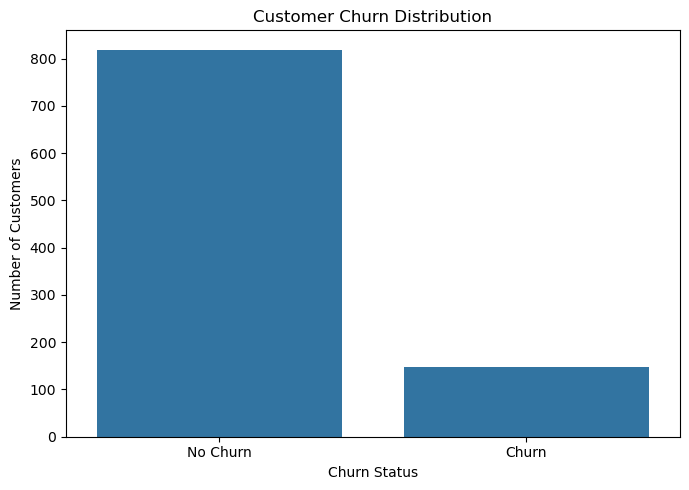

In [56]:
# ============================================
# CELL 16 — EDA WITH CHURN
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=customer_features_final,
    x="is_churned"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.tight_layout()
plt.show()

# BUSINESS QUESTIONS

The exploratory analysis is conducted to answer the following business questions:

1. What characteristics are associated with customers who churn?
2. Is transaction activity associated with customer churn?
3. Is customer engagement associated with churn?
4. Which factors are most influential in predicting customer churn?
5. How well can Machine Learning identify customers at risk of churn?

### Business Question 1 — Interpretation

Customer characteristics are compared based on churn rate across customer segment, gender, and acquisition channel.

The analysis identifies which customer groups have relatively higher churn rates and can therefore be considered for further behavioral analysis.

The findings are based on the observed churn rates in the prepared customer-level dataset.

In [62]:
# ============================================
# BUSINESS QUESTION 1
# CUSTOMER CHARACTERISTICS AND CHURN
# ============================================

print("=" * 60)
print("BUSINESS QUESTION 1")
print("=" * 60)

print(
    "\nQuestion:"
    "\nWhat characteristics are associated with customers who churn?"
)

print("\n=== CHURN RATE BY CUSTOMER SEGMENT ===")

segment_churn_analysis = (
    customer_features_final
    .groupby("customer_segment")["is_churned"]
    .agg(
        customer_count="count",
        churn_rate="mean"
    )
    .reset_index()
)

segment_churn_analysis["churn_rate"] = (
    segment_churn_analysis["churn_rate"] * 100
)

display(
    segment_churn_analysis
    .sort_values("churn_rate", ascending=False)
    .round(2)
)

print("\n=== CHURN RATE BY GENDER ===")

gender_churn_analysis = (
    customer_features_final
    .groupby("gender")["is_churned"]
    .agg(
        customer_count="count",
        churn_rate="mean"
    )
    .reset_index()
)

gender_churn_analysis["churn_rate"] = (
    gender_churn_analysis["churn_rate"] * 100
)

display(
    gender_churn_analysis
    .sort_values("churn_rate", ascending=False)
    .round(2)
)

print("\n=== CHURN RATE BY ACQUISITION CHANNEL ===")

channel_churn_analysis = (
    customer_features_final
    .groupby("acquisition_channel")["is_churned"]
    .agg(
        customer_count="count",
        churn_rate="mean"
    )
    .reset_index()
)

channel_churn_analysis["churn_rate"] = (
    channel_churn_analysis["churn_rate"] * 100
)

display(
    channel_churn_analysis
    .sort_values("churn_rate", ascending=False)
    .round(2)
)

BUSINESS QUESTION 1

Question:
What characteristics are associated with customers who churn?

=== CHURN RATE BY CUSTOMER SEGMENT ===


,customer_segment,customer_count,churn_rate
1,low,139,93.53
2,medium,573,2.97
0,high,255,0.39



=== CHURN RATE BY GENDER ===


,gender,customer_count,churn_rate
1,male,467,15.42
0,female,465,15.27
2,other,35,14.29



=== CHURN RATE BY ACQUISITION CHANNEL ===


,acquisition_channel,customer_count,churn_rate
2,referral,205,15.61
0,ads,390,15.38
1,organic,372,15.05


### Business Question 2 — Interpretation

Transaction behavior is compared between churned and non-churned customers using transaction frequency, spending, average transaction value, and product diversity.

These comparisons are used to determine whether differences in transaction activity are associated with customer churn.

In [64]:
# ============================================
# BUSINESS QUESTION 2
# TRANSACTION ACTIVITY AND CHURN
# ============================================

print("=" * 60)
print("BUSINESS QUESTION 2")
print("=" * 60)

print(
    "\nQuestion:"
    "\nIs transaction activity associated with customer churn?"
)

transaction_churn_analysis = (
    customer_features_final
    .groupby("is_churned")[
        [
            "total_transactions",
            "total_spending",
            "average_transaction_value",
            "purchase_frequency",
            "unique_products"
        ]
    ]
    .mean()
)

transaction_churn_analysis.index = [
    "No Churn",
    "Churn"
]

print("\n=== AVERAGE TRANSACTION BEHAVIOR BY CHURN STATUS ===")

display(
    transaction_churn_analysis.round(2)
)

BUSINESS QUESTION 2

Question:
Is transaction activity associated with customer churn?

=== AVERAGE TRANSACTION BEHAVIOR BY CHURN STATUS ===


,total_transactions,total_spending,average_transaction_value,purchase_frequency,unique_products
No Churn,23.46,418452.85,18119.41,23.46,19.96
Churn,2.91,48037.83,15944.40,2.91,2.80


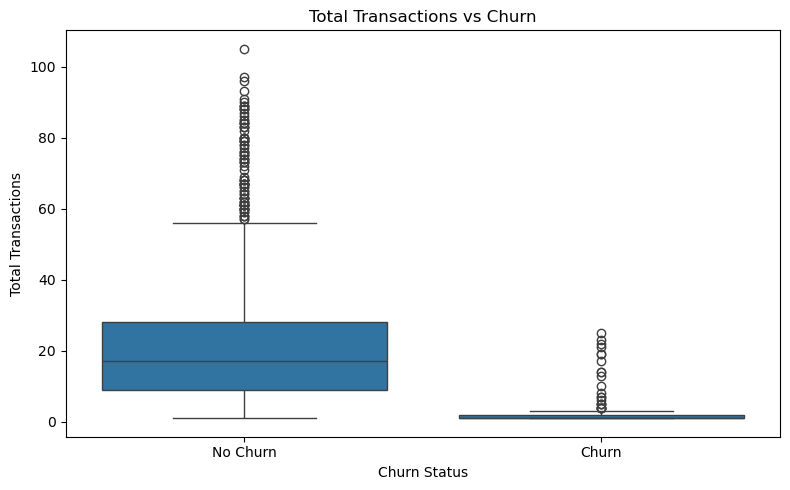

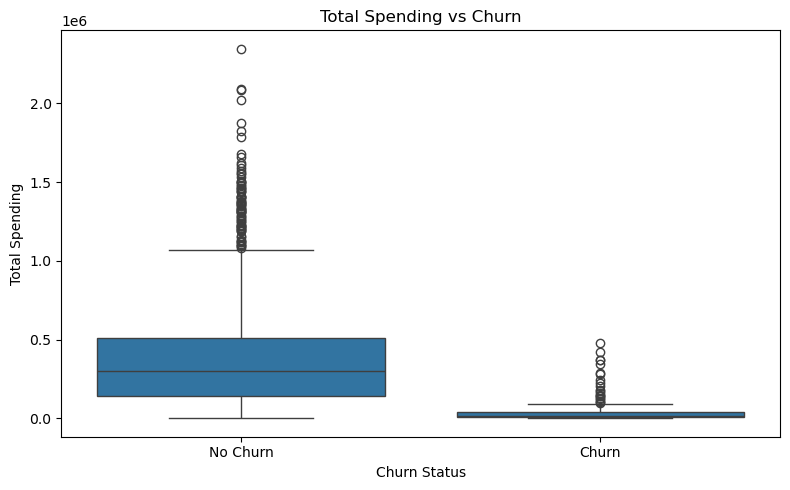

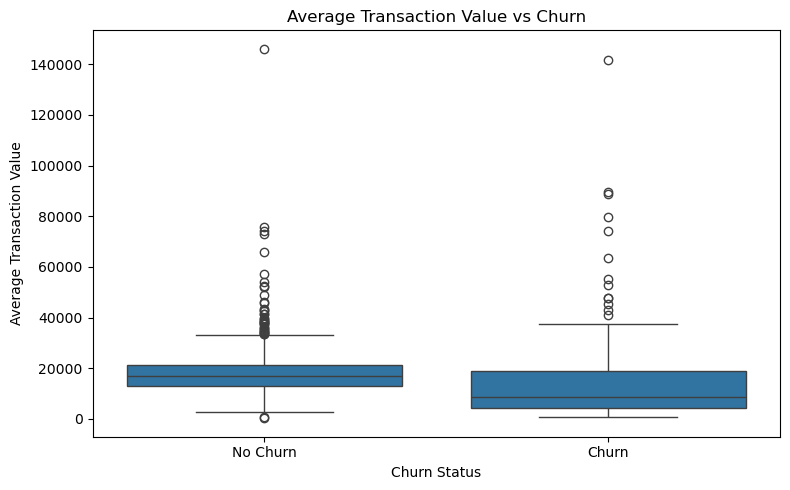

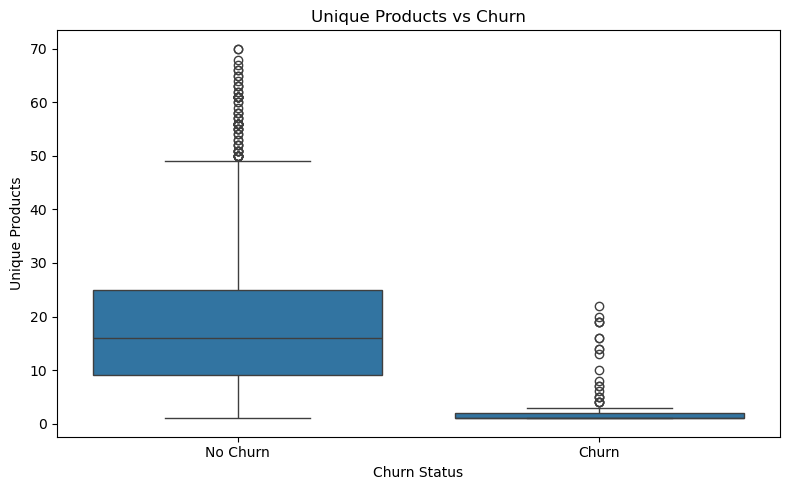

In [65]:
# ============================================
# TRANSACTION ACTIVITY VS CHURN
# ============================================

transaction_metrics = [
    "total_transactions",
    "total_spending",
    "average_transaction_value",
    "unique_products"
]

for metric in transaction_metrics:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=customer_features_final,
        x="is_churned",
        y=metric
    )

    plt.title(
        f"{metric.replace('_', ' ').title()} vs Churn"
    )

    plt.xlabel("Churn Status")
    plt.ylabel(metric.replace("_", " ").title())

    plt.xticks(
        [0, 1],
        ["No Churn", "Churn"]
    )

    plt.tight_layout()
    plt.show()

=== CHURN RATE BY PURCHASE FREQUENCY ===
frequency_group
Low          70.48
Medium       16.84
High          3.88
Very High     1.73
Name: is_churned, dtype: float64


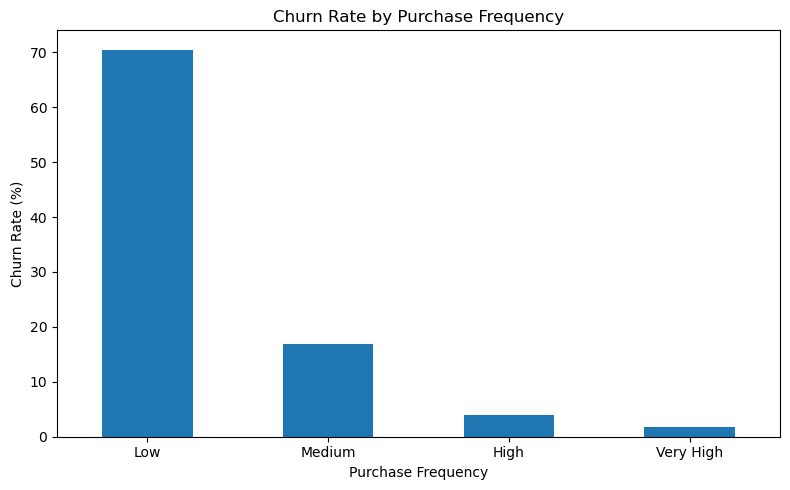

In [66]:
# ============================================
# PURCHASE FREQUENCY VS CHURN
# ============================================

customer_features_final["frequency_group"] = pd.cut(
    customer_features_final["total_transactions"],
    bins=[0, 2, 5, 10, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

frequency_churn = (
    customer_features_final
    .groupby(
        "frequency_group",
        observed=False
    )["is_churned"]
    .mean()
    .mul(100)
)

print("=== CHURN RATE BY PURCHASE FREQUENCY ===")

print(
    frequency_churn.round(2)
)

plt.figure(figsize=(8, 5))

frequency_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Question 3 — Interpretation

Customer engagement is compared between churned and non-churned customers using interaction volume, website visits, marketing interactions, engagement frequency, and interaction type diversity.

The analysis is used to determine whether differences in customer engagement are associated with churn.

In [69]:
# ============================================
# BUSINESS QUESTION 3
# CUSTOMER ENGAGEMENT AND CHURN
# ============================================

print("=" * 60)
print("BUSINESS QUESTION 3")
print("=" * 60)

print(
    "\nQuestion:"
    "\nIs customer engagement associated with churn?"
)

engagement_churn_analysis = (
    customer_features_final
    .groupby("is_churned")[
        [
            "total_interactions",
            "website_visits",
            "marketing_interactions",
            "engagement_frequency",
            "interaction_types_count"
        ]
    ]
    .mean()
)

engagement_churn_analysis.index = [
    "No Churn",
    "Churn"
]

print("\n=== AVERAGE ENGAGEMENT BEHAVIOR BY CHURN STATUS ===")

display(
    engagement_churn_analysis.round(2)
)

BUSINESS QUESTION 3

Question:
Is customer engagement associated with churn?

=== AVERAGE ENGAGEMENT BEHAVIOR BY CHURN STATUS ===


,total_interactions,website_visits,marketing_interactions,engagement_frequency,interaction_types_count
No Churn,235.85,0.0,23.47,0.33,3.98
Churn,40.03,0.0,3.80,0.06,3.63


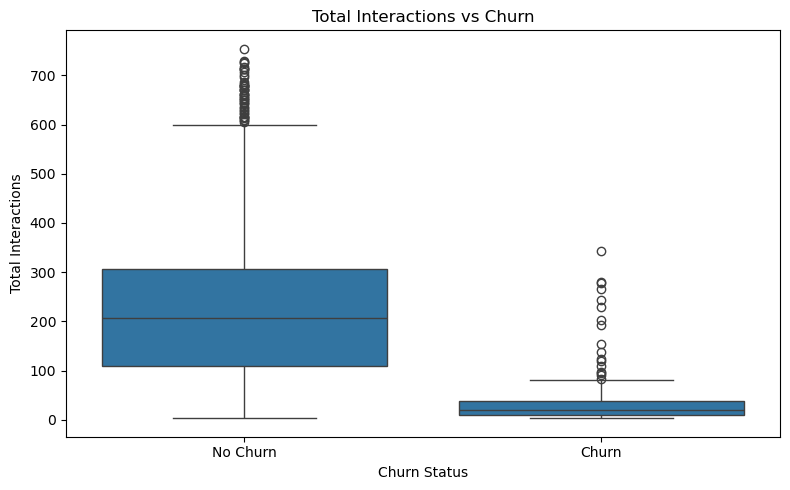

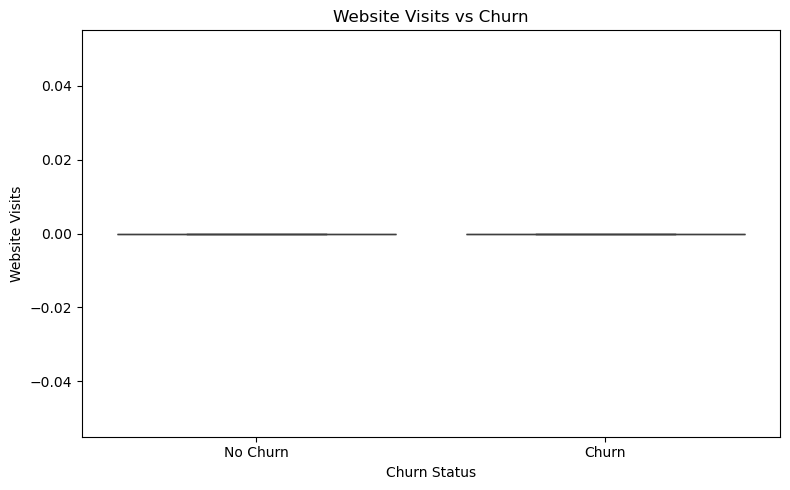

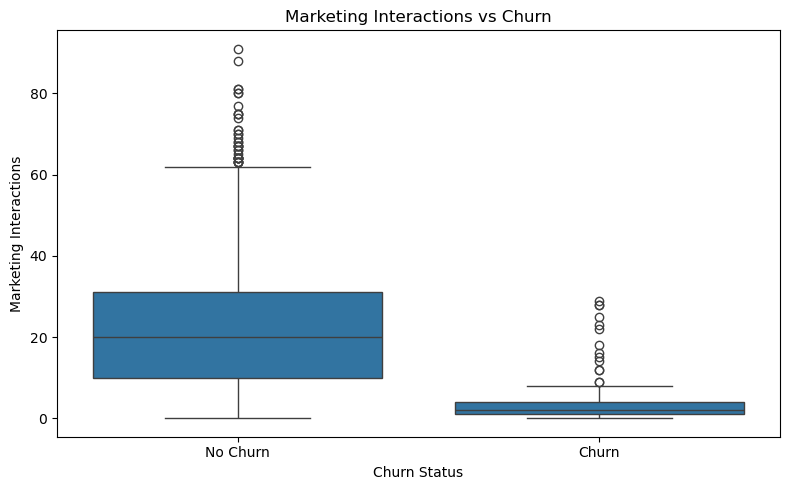

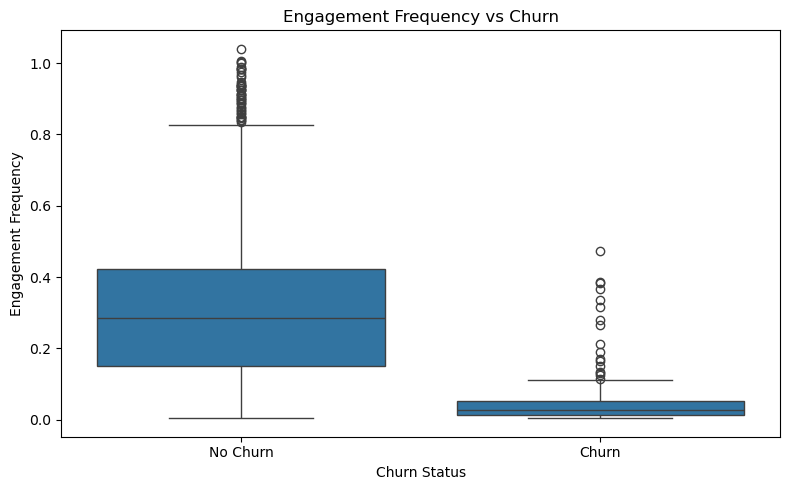

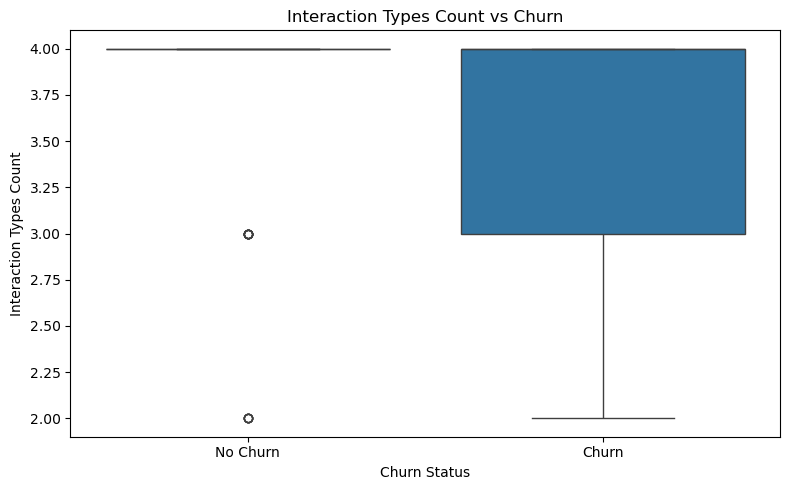

In [70]:
# ============================================
# ENGAGEMENT BEHAVIOR VS CHURN
# ============================================

engagement_metrics = [
    "total_interactions",
    "website_visits",
    "marketing_interactions",
    "engagement_frequency",
    "interaction_types_count"
]

for metric in engagement_metrics:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=customer_features_final,
        x="is_churned",
        y=metric
    )

    plt.title(
        f"{metric.replace('_', ' ').title()} vs Churn"
    )

    plt.xlabel("Churn Status")
    plt.ylabel(metric.replace("_", " ").title())

    plt.xticks(
        [0, 1],
        ["No Churn", "Churn"]
    )

    plt.tight_layout()
    plt.show()

=== CHURN RATE BY ENGAGEMENT LEVEL ===
interaction_group
Low          78.64
Medium       25.23
High          2.78
Very High     1.61
Name: is_churned, dtype: float64


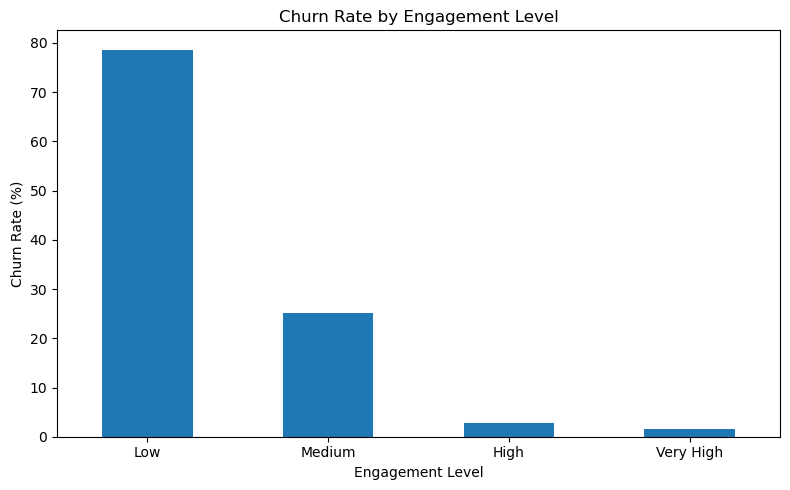

In [72]:
# ============================================
# INTERACTION LEVEL VS CHURN
# ============================================

customer_features_final["interaction_group"] = pd.cut(
    customer_features_final["total_interactions"],
    bins=[-1, 20, 100, 200, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

interaction_churn = (
    customer_features_final
    .groupby(
        "interaction_group",
        observed=False
    )["is_churned"]
    .mean()
    .mul(100)
)

print("=== CHURN RATE BY ENGAGEMENT LEVEL ===")

print(
    interaction_churn.round(2)
)

plt.figure(figsize=(8, 5))

interaction_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 16. Machine Learning Model Preparation

In [75]:
# ============================================
# CELL 19 — MODEL PREPARATION
# ============================================

features = [
    # Customer Profile
    "customer_segment",
    "location",
    "acquisition_channel",
    "age",
    "gender",

    # Transaction Behavior
    "total_transactions",
    "total_spending",
    "average_transaction_value",
    "purchase_frequency",
    "unique_products",

    # Engagement Behavior
    "total_interactions",
    "website_visits",
    "marketing_interactions",
    "engagement_frequency",
    "interaction_types_count",

    # Recency / Activity
    "days_since_last_purchase",
    "days_since_last_interaction",
    "customer_lifetime"
]

X = customer_features_final[
    features
].copy()

y = customer_features_final[
    "is_churned"
].copy()

print("=== MODEL DATA ===")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

=== MODEL DATA ===
X shape: (967, 18)
y shape: (967,)

Features:
['customer_segment', 'location', 'acquisition_channel', 'age', 'gender', 'total_transactions', 'total_spending', 'average_transaction_value', 'purchase_frequency', 'unique_products', 'total_interactions', 'website_visits', 'marketing_interactions', 'engagement_frequency', 'interaction_types_count', 'days_since_last_purchase', 'days_since_last_interaction', 'customer_lifetime']

Missing values:
customer_segment               0
location                       0
acquisition_channel            0
age                            0
gender                         0
total_transactions             0
total_spending                 0
average_transaction_value      0
purchase_frequency             0
unique_products                0
total_interactions             0
website_visits                 0
marketing_interactions         0
engagement_frequency           0
interaction_types_count        0
days_since_last_purchase       0
days_since

In [76]:
# ============================================
# CELL 20 — TRAIN TEST SPLIT & PREPROCESSING
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (773, 18)
X_test : (194, 18)

y_train:
is_churned
0    655
1    118
Name: count, dtype: int64

y_test:
is_churned
0    164
1     30
Name: count, dtype: int64


In [77]:
# ============================================
# PREPROCESSING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

numeric_features = [
    "age",
    "total_transactions",
    "total_spending",
    "average_transaction_value",
    "purchase_frequency",
    "unique_products",
    "total_interactions",
    "website_visits",
    "marketing_interactions",
    "engagement_frequency",
    "interaction_types_count",
    "days_since_last_purchase",
    "days_since_last_interaction",
    "customer_lifetime"
]

categorical_features = [
    "customer_segment",
    "location",
    "acquisition_channel",
    "gender"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 14
Categorical features: 4


## 17. Machine Learning Modeling

### 17.1 Logistic Regression

In [80]:
# ============================================
# CELL 21 — LOGISTIC REGRESSION
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_pred = logistic_pipeline.predict(
    X_test
)

logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression successfully trained!")

Logistic Regression successfully trained!


### 17.2 Decision Tree

In [82]:
# ============================================
# CELL 22 — DECISION TREE
# ============================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42,
                max_depth=8,
                min_samples_leaf=5
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

decision_tree_pred = decision_tree_pipeline.predict(
    X_test
)

decision_tree_prob = (
    decision_tree_pipeline
    .predict_proba(X_test)[:, 1]
)

print("Decision Tree successfully trained!")

Decision Tree successfully trained!


### 17.3 Random Forest

In [84]:
# ============================================
# CELL 23 — RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

random_forest_pred = (
    random_forest_pipeline.predict(X_test)
)

random_forest_prob = (
    random_forest_pipeline
    .predict_proba(X_test)[:, 1]
)

print("Random Forest successfully trained!")

Random Forest successfully trained!


## 18. Model Comparison

### Model Comparison Interpretation

Three classification models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Random Forest achieved the best overall performance with an F1-Score of 0.947 and ROC-AUC of 0.978. It also achieved 98.5% accuracy, 100% precision, and 90% recall on the test set.

Because customer churn is a relatively imbalanced classification problem, F1-Score and Recall are considered important evaluation metrics. Based on the overall evaluation results, Random Forest was selected as the final model.

In [89]:
# ============================================
# CELL 24 — MODEL COMPARISON
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }


model_comparison = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_pred,
        decision_tree_prob
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_pred,
        random_forest_prob
    )
])

model_comparison = model_comparison.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

print("=== MODEL COMPARISON ===")

display(
    model_comparison.round(3)
)

=== MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.985,1.000,0.9,0.947,0.978
1,Logistic Regression,0.959,0.844,0.9,0.871,0.966
2,Decision Tree,0.907,0.643,0.9,0.750,0.944


## 19. Model Evaluation

In [92]:
# ============================================
# CELL 25 — MODEL EVALUATION
# ============================================

from sklearn.metrics import classification_report

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

print("=" * 60)
print("DECISION TREE")
print("=" * 60)

print(
    classification_report(
        y_test,
        decision_tree_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test,
        random_forest_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    No Churn       0.98      0.97      0.98       164
       Churn       0.84      0.90      0.87        30

    accuracy                           0.96       194
   macro avg       0.91      0.93      0.92       194
weighted avg       0.96      0.96      0.96       194

DECISION TREE
              precision    recall  f1-score   support

    No Churn       0.98      0.91      0.94       164
       Churn       0.64      0.90      0.75        30

    accuracy                           0.91       194
   macro avg       0.81      0.90      0.85       194
weighted avg       0.93      0.91      0.91       194

RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       164
       Churn       1.00      0.90      0.95        30

    accuracy                           0.98       194
   macro avg       0.99      0.95      0.97       194
weighted avg       0.98   

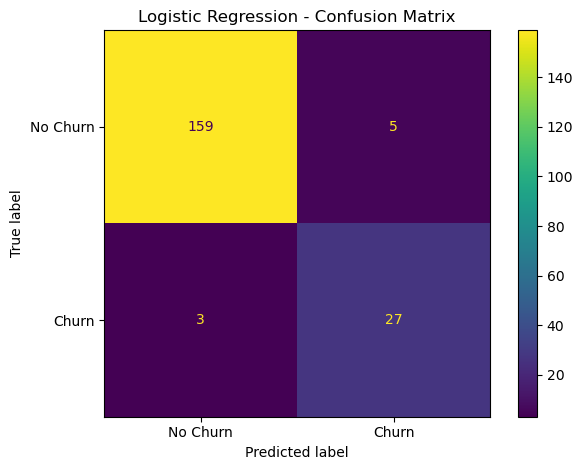

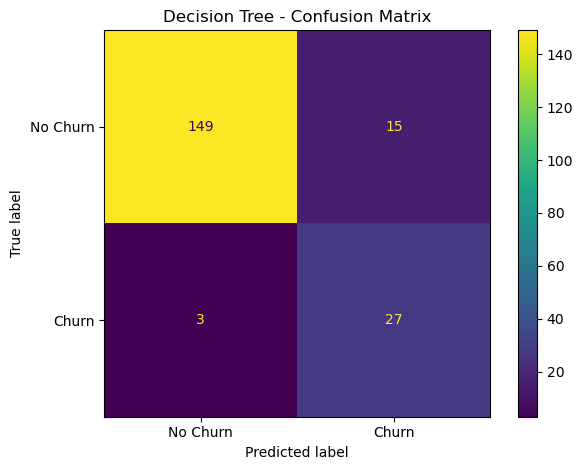

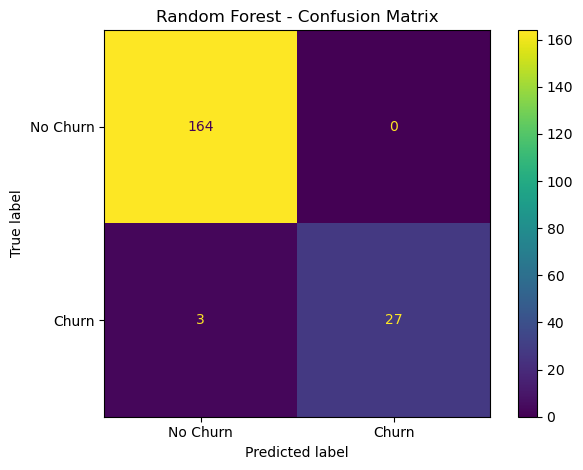

In [93]:
# ============================================
# CONFUSION MATRICES
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay

model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

for model_name, predictions in model_predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=[
            "No Churn",
            "Churn"
        ]
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

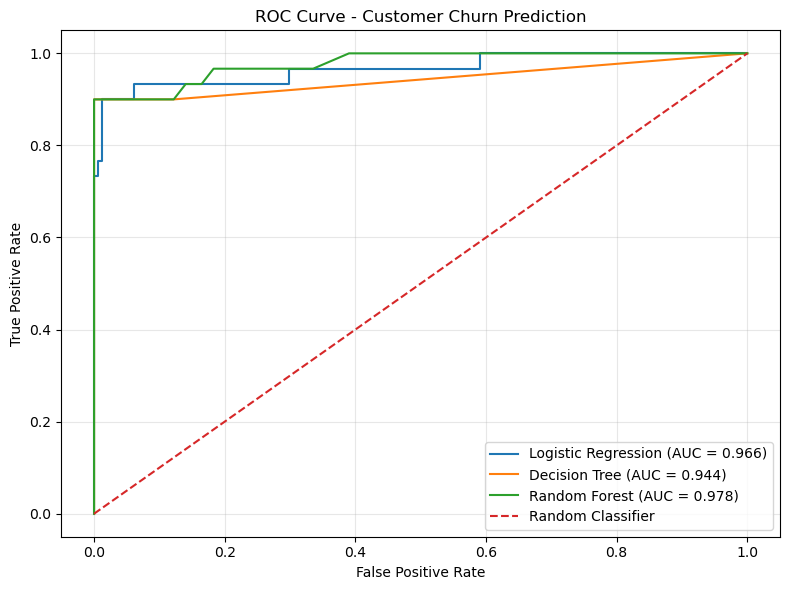

In [94]:
# ============================================
# CELL 26 — ROC CURVE
# ============================================

from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_prob
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    decision_tree_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    random_forest_prob
)

auc_logistic = roc_auc_score(
    y_test,
    logistic_prob
)

auc_tree = roc_auc_score(
    y_test,
    decision_tree_prob
)

auc_rf = roc_auc_score(
    y_test,
    random_forest_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Customer Churn Prediction"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
# ============================================
# CELL 27 — FINAL MODEL SELECTION
# ============================================

best_model_name = model_comparison.loc[
    0,
    "Model"
]

print("=== FINAL MODEL SELECTION ===")

print(
    "Selected Model:",
    best_model_name
)

print(
    "\nSelection is based primarily on F1-Score, "
    "while considering Recall, Precision, Accuracy, "
    "and ROC-AUC."
)

display(
    model_comparison.round(3)
)

=== FINAL MODEL SELECTION ===
Selected Model: Random Forest

Selection is based primarily on F1-Score, while considering Recall, Precision, Accuracy, and ROC-AUC.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.985,1.000,0.9,0.947,0.978
1,Logistic Regression,0.959,0.844,0.9,0.871,0.966
2,Decision Tree,0.907,0.643,0.9,0.750,0.944


In [96]:
# ============================================
# SELECT FINAL MODEL OBJECT
# ============================================

model_objects = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

final_model = model_objects[
    best_model_name
]

print(
    "Final model object:",
    best_model_name
)

Final model object: Random Forest


## 20. Feature Importance

### Feature Importance Interpretation

The feature importance analysis shows that customer segment, recency-related variables, purchase frequency, and transaction behavior are among the most influential features used by the Random Forest model.

The most influential feature was the low customer segment category, followed by days since the last interaction, days since the last purchase, purchase frequency, and unique products.

These results indicate that both customer characteristics and behavioral activity contribute to the model's churn prediction.

=== TOP 10 FEATURE IMPORTANCE ===


,feature,importance
0,cat__customer_segment_low,0.183388
1,num__days_since_last_interaction,0.104594
2,num__days_since_last_purchase,0.095600
3,num__purchase_frequency,0.088023
4,num__unique_products,0.072949
5,num__total_transactions,0.065895
6,num__total_spending,0.065509
7,num__total_interactions,0.055064
8,num__engagement_frequency,0.054639
9,num__marketing_interactions,0.051510


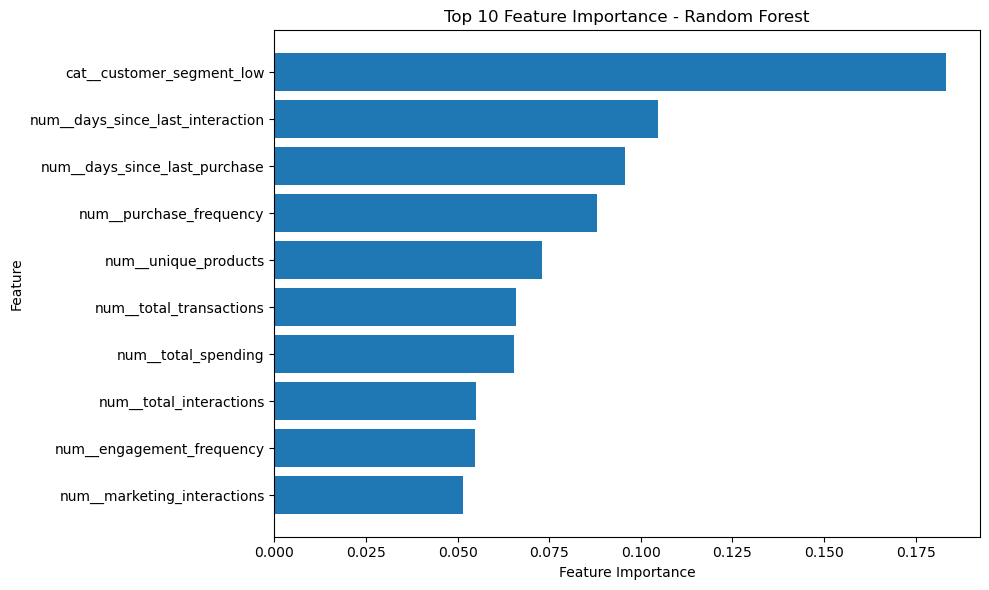

In [99]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

if best_model_name in [
    "Decision Tree",
    "Random Forest"
]:

    model_step = final_model.named_steps["model"]
    fitted_preprocessor = (
        final_model.named_steps["preprocessor"]
    )

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    importance_values = (
        model_step.feature_importances_
    )

    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("=== TOP 10 FEATURE IMPORTANCE ===")

    display(
        feature_importance.head(10)
    )

    top_features = (
        feature_importance
        .head(10)
        .sort_values(
            "importance"
        )
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["feature"],
        top_features["importance"]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.title(
        f"Top 10 Feature Importance - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "Logistic Regression selected."
    )

    print(
        "Feature importance will be interpreted "
        "using model coefficients."
    )

In [100]:
# ============================================
# CELL 28 — FINAL MODEL EVALUATION
# ============================================

final_prediction = final_model.predict(
    X_test
)

final_probability = (
    final_model
    .predict_proba(X_test)[:, 1]
)

final_accuracy = accuracy_score(
    y_test,
    final_prediction
)

final_precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probability
)

print("=== FINAL MODEL PERFORMANCE ===")

print(
    "Model     :", best_model_name
)

print(
    "Accuracy  :",
    round(final_accuracy, 3)
)

print(
    "Precision :",
    round(final_precision, 3)
)

print(
    "Recall    :",
    round(final_recall, 3)
)

print(
    "F1-Score  :",
    round(final_f1, 3)
)

print(
    "ROC-AUC   :",
    round(final_roc_auc, 3)
)

=== FINAL MODEL PERFORMANCE ===
Model     : Random Forest
Accuracy  : 0.985
Precision : 1.0
Recall    : 0.9
F1-Score  : 0.947
ROC-AUC   : 0.978


## 21. Customer Churn Prediction

In [103]:
# ============================================
# CUSTOMER CHURN PREDICTION OUTPUT
# ============================================

prediction_output = X_test.copy()

prediction_output.insert(
    0,
    "customer_id",
    customer_features_final.loc[
        X_test.index,
        "customer_id"
    ].values
)

prediction_output["actual"] = (
    y_test.values
)

prediction_output["churn_prediction"] = (
    final_prediction
)

prediction_output["churn_probability"] = (
    final_probability
)

prediction_output["prediction_label"] = (
    prediction_output["churn_prediction"]
    .map({
        0: "No Churn",
        1: "Churn"
    })
)

prediction_output = prediction_output[
    [
        "customer_id",
        "actual",
        "churn_prediction",
        "prediction_label",
        "churn_probability"
    ]
]

prediction_output = prediction_output.sort_values(
    "churn_probability",
    ascending=False
)

print("=== CUSTOMER CHURN PREDICTION ===")

display(
    prediction_output.head(20)
)

=== CUSTOMER CHURN PREDICTION ===


,customer_id,actual,churn_prediction,prediction_label,churn_probability
707,C00708,1,1,Churn,1.000000
970,C00971,1,1,Churn,0.996667
599,C00600,1,1,Churn,0.993333
400,C00401,1,1,Churn,0.990000
22,C00023,1,1,Churn,0.990000
948,C00949,1,1,Churn,0.986667
354,C00355,1,1,Churn,0.983333
1223,C01224,1,1,Churn,0.980000
834,C00835,1,1,Churn,0.980000
721,C00722,1,1,Churn,0.973333


## 22. Business Insights

### Business Insights Interpretation

The analysis shows an overall churn rate of 15.31% among the customers included in the final analytical dataset.

Customers in the low customer segment showed the highest churn rate at 93.53%. Customers in the low purchase-frequency group also showed a high churn rate of 70.48%.

The engagement analysis shows that customers in the low engagement group had the highest churn rate at 78.64%.

The behavioral comparison also shows a substantial difference between churned and non-churned customers. Churned customers had lower average transaction activity, spending, and interaction activity compared with customers who did not churn.

In [108]:
# ============================================
# BUSINESS INSIGHTS
# ============================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

# --------------------------------------------
# 1. Overall Churn Rate
# --------------------------------------------

overall_churn_rate = (
    customer_features_final["is_churned"]
    .mean() * 100
)

print(
    f"\n1. Overall churn rate: "
    f"{overall_churn_rate:.2f}%"
)


# --------------------------------------------
# 2. Customer Segment Churn
# --------------------------------------------

segment_summary = (
    customer_features_final
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_id", "count"),
        churn_rate=("is_churned", "mean")
    )
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

segment_summary["churn_rate"] = (
    segment_summary["churn_rate"] * 100
)

print("\n2. Churn rate by customer segment:")
display(
    segment_summary.round(2)
)


# --------------------------------------------
# 3. Purchase Frequency Churn
# --------------------------------------------

frequency_summary = (
    customer_features_final
    .groupby(
        "frequency_group",
        observed=False
    )
    .agg(
        customer_count=("customer_id", "count"),
        churn_rate=("is_churned", "mean")
    )
    .dropna()
)

frequency_summary["churn_rate"] = (
    frequency_summary["churn_rate"] * 100
)

print("\n3. Churn rate by purchase frequency:")
display(
    frequency_summary.round(2)
)


# --------------------------------------------
# 4. Engagement Churn
# --------------------------------------------

engagement_summary = (
    customer_features_final
    .groupby(
        "interaction_group",
        observed=False
    )
    .agg(
        customer_count=("customer_id", "count"),
        churn_rate=("is_churned", "mean")
    )
    .dropna()
)

engagement_summary["churn_rate"] = (
    engagement_summary["churn_rate"] * 100
)

print("\n4. Churn rate by engagement level:")
display(
    engagement_summary.round(2)
)


# --------------------------------------------
# 5. Transaction Behavior Comparison
# --------------------------------------------

transaction_insight = (
    customer_features_final
    .groupby("is_churned")[
        [
            "total_transactions",
            "total_spending",
            "unique_products"
        ]
    ]
    .mean()
)

transaction_insight.index = [
    "No Churn",
    "Churn"
]

print("\n5. Transaction behavior comparison:")
display(
    transaction_insight.round(2)
)


# --------------------------------------------
# 6. Engagement Behavior Comparison
# --------------------------------------------

engagement_insight = (
    customer_features_final
    .groupby("is_churned")[
        [
            "total_interactions",
            "marketing_interactions",
            "engagement_frequency"
        ]
    ]
    .mean()
)

engagement_insight.index = [
    "No Churn",
    "Churn"
]

print("\n6. Engagement behavior comparison:")
display(
    engagement_insight.round(2)
)

BUSINESS INSIGHTS

1. Overall churn rate: 15.31%

2. Churn rate by customer segment:


,customer_count,churn_rate
customer_segment,,
low,139,93.53
medium,573,2.97
high,255,0.39



3. Churn rate by purchase frequency:


,customer_count,churn_rate
frequency_group,,
Low,166,70.48
Medium,95,16.84
High,129,3.88
Very High,577,1.73



4. Churn rate by engagement level:


,customer_count,churn_rate
interaction_group,,
Low,103,78.64
Medium,214,25.23
High,216,2.78
Very High,434,1.61



5. Transaction behavior comparison:


,total_transactions,total_spending,unique_products
No Churn,23.46,418452.85,19.96
Churn,2.91,48037.83,2.80



6. Engagement behavior comparison:


,total_interactions,marketing_interactions,engagement_frequency
No Churn,235.85,23.47,0.33
Churn,40.03,3.80,0.06


## 23. Business Recommendations

### Business Recommendations

Based on the analysis and model results, the following customer retention strategies are recommended:

1. **Prioritize high-risk customers**
   
   Use the churn probability generated by the Random Forest model to prioritize customers with a high predicted risk of churn for retention activities.

2. **Focus on low purchase activity**
   
   Customers with lower transaction frequency and fewer purchased products should be monitored and considered for targeted retention campaigns.

3. **Improve customer engagement**
   
   Customers with low interaction activity and low engagement frequency may require more relevant communication and personalized engagement strategies.

4. **Prioritize the low customer segment**
   
   The low customer segment shows the highest observed churn rate, making it an important group for further investigation and targeted retention strategies.

5. **Use behavioral data for customer segmentation**
   
   Transaction and engagement behavior can be incorporated into retention strategies to identify different customer risk profiles.

6. **Use predictions as a prioritization tool**
   
   Churn predictions should support retention decisions rather than being treated as guaranteed customer outcomes.

In [113]:
# ============================================
# BUSINESS RECOMMENDATIONS
# ============================================

print("=" * 60)
print("CUSTOMER RETENTION RECOMMENDATIONS")
print("=" * 60)

print(
    "\n1. Prioritize customers with high predicted churn probability "
    "for proactive retention campaigns."
)

print(
    "\n2. Pay closer attention to customers with low purchase activity, "
    "as churned customers showed substantially lower transaction "
    "frequency and spending than non-churned customers."
)

print(
    "\n3. Increase engagement among low-engagement customers through "
    "relevant communication, personalized offers, and targeted "
    "marketing campaigns."
)

print(
    "\n4. Develop segment-specific retention strategies, especially "
    "for customer segments with higher observed churn rates."
)

print(
    "\n5. Monitor customers with increasing days since their last "
    "purchase or interaction as potential early churn signals."
)

print(
    "\n6. Use the churn prediction output as a prioritization tool "
    "for retention activities rather than treating predictions as "
    "guaranteed customer outcomes."
)

CUSTOMER RETENTION RECOMMENDATIONS

1. Prioritize customers with high predicted churn probability for proactive retention campaigns.

2. Pay closer attention to customers with low purchase activity, as churned customers showed substantially lower transaction frequency and spending than non-churned customers.

3. Increase engagement among low-engagement customers through relevant communication, personalized offers, and targeted marketing campaigns.

4. Develop segment-specific retention strategies, especially for customer segments with higher observed churn rates.

5. Monitor customers with increasing days since their last purchase or interaction as potential early churn signals.

6. Use the churn prediction output as a prioritization tool for retention activities rather than treating predictions as guaranteed customer outcomes.


In [115]:
# ============================================
# CELL 29 — SAVE FINAL OUTPUT
# ============================================

PROCESSED_PATH = (
    "D:/PORTO/customer-churn-prediction/data/processed"
)

MODEL_PATH = (
    "D:/PORTO/customer-churn-prediction/models"
)

os.makedirs(
    PROCESSED_PATH,
    exist_ok=True
)

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)

# --------------------------------------------
# Save final customer-level dataset
# --------------------------------------------

final_dataset_path = os.path.join(
    PROCESSED_PATH,
    "customer_features_FINAL.csv"
)

customer_features_final.to_csv(
    final_dataset_path,
    index=False
)

# --------------------------------------------
# Save prediction output
# --------------------------------------------

prediction_path = os.path.join(
    PROCESSED_PATH,
    "customer_churn_predictions_FINAL.csv"
)

prediction_output.to_csv(
    prediction_path,
    index=False
)

# --------------------------------------------
# Save model
# --------------------------------------------

model_path = os.path.join(
    MODEL_PATH,
    "best_churn_FINAL.pkl"
)

joblib.dump(
    final_model,
    model_path
)

print("=== FINAL OUTPUT SAVED ===")

print(
    "\nCustomer features:",
    final_dataset_path
)

print(
    "\nPrediction output:",
    prediction_path
)

print(
    "\nFinal model:",
    model_path
)

print("\nProject pipeline completed successfully!")

=== FINAL OUTPUT SAVED ===

Customer features: D:/PORTO/customer-churn-prediction/data/processed\customer_features_FINAL.csv

Prediction output: D:/PORTO/customer-churn-prediction/data/processed\customer_churn_predictions_FINAL.csv

Final model: D:/PORTO/customer-churn-prediction/models\best_churn_FINAL.pkl

Project pipeline completed successfully!


## Final Project Summary

This project developed an end-to-end customer churn prediction pipeline using customer profile, transaction, and engagement data.

The workflow included data validation, data cleaning, exploratory data analysis, data integration, behavioral feature engineering, churn target definition, machine learning modeling, model comparison, evaluation, feature importance analysis, and business interpretation.

Among the evaluated models, Random Forest achieved the strongest overall performance with an F1-Score of 0.947 and ROC-AUC of 0.978.

The resulting churn prediction output can be used as a prioritization tool to support customer retention activities.

In [116]:
model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.985,1.000,0.9,0.947,0.978
1,Logistic Regression,0.959,0.844,0.9,0.871,0.966
2,Decision Tree,0.907,0.643,0.9,0.750,0.944
